# Cartilage Data Analysis

*Date: 16 July, 2026 - BY: Tomás Silva*

Tasks:
 - Import Dataset
 - Generate 3 stacked 2D plots using these specific features: `total intensity`, `total collagen` and `rho_new`.
    -   `rho_new`: degree of orientation, representing how aligned the collagen fibers are at one point
 - Define Evaluation Metric Functins
 - Run Models using different scalers: `StandardScaler`, `MinMaxScaler` and `RobustScaler`
 - Run Models using different features:
    - Primary Set: total SAXS intensity ($totalint$), total Collagen Intensity ($totalcol$), Degree of orientation ($rho_new$)
    - Microstructural features: Degree of orientation ($rho_new$), peak area ($wa2$), collagen D-spacing ($Dnew2$), fibril diameter ($Diameter2$)
    - Run with all 7 features combined
 - Run models using different values for min_samples {5, 10, 13}
 - Run models using control samples vs low injury vs high injury

 ### 1. Imports & Setting Up the Notebook


In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
import hdbscan

# Color palette
palette_base = sns.color_palette("Set1")
my_colors = {-1: 'black'}
for i in range(50):
    my_colors[i] = palette_base[i % len(palette_base)]
print("Universal HDBSCAN color palette ready!")

Universal HDBSCAN color palette ready!


### 2. Import Dataset & Selecting Sample

In [19]:
df_import = pd.read_csv('Cartilage/master_data_file_v2_hsg.csv')
print(df_import.shape)

# Samples in the dataset
samples_id = df_import['sample no'].unique()
num_samples = len(samples_id)
print(f"\n{'-'*25}")
print(f"There are {num_samples} unique samples in this master dataset.")
print(f"\nThe sample IDs are: {samples_id}")
print(f"{'-'*25}")

# Generate a pair table with each sample category
info_df = df_import[['sample no', 'State', 'Group', 'Sample']].drop_duplicates()

unloaded_df = info_df[info_df['State'] == 'unloaded'].sort_values('sample no').reset_index(drop=True)
loaded_df = info_df[info_df['State'] == 'loaded'].sort_values('sample no').reset_index(drop=True)

pair_table = pd.DataFrame({
    'Unloaded_ID': unloaded_df['sample no'],
    'Loaded_ID': loaded_df['sample no'],
    'Condition': unloaded_df['Sample'], 
    'Treatment': unloaded_df['Group'] 
})
display(pair_table)

# Save
# pair_table.to_csv('Cartilage/Samples_inventory.csv', index=False)
# print('Samples_invetory saved as CSV.')

(47498, 17)

-------------------------
There are 60 unique samples in this master dataset.

The sample IDs are: [599112 599118 599124 599130 599134 599113 599119 599125 599131 599135
 599114 599120 599126 599132 599143 599115 599121 599127 599133 599144
 599116 599122 599128 599145 599147 599117 599123 599129 599146 599148
 599170 599177 599196 599202 599204 599171 599178 599197 599203 599205
 599161 599173 599179 599192 599198 599166 599174 599180 599193 599199
 599167 599175 599181 599194 599200 599168 599176 599182 599195 599201]
-------------------------


,Unloaded_ID,Loaded_ID,Condition,Treatment
0,599112,599113,control,untreated
1,599114,599115,lowinjury,untreated
2,599116,599117,highinjury,untreated
3,599118,599119,control,untreated
4,599120,599121,lowinjury,untreated
5,599122,599123,highinjury,untreated
6,599124,599125,control,untreated
7,599126,599127,lowinjury,untreated
8,599128,599129,highinjury,untreated
9,599130,599131,control,untreated


In [20]:
# Choosing the sample to analyse
sample_num = 599133

# Slice the data using the sample
df_slice = df_import[df_import['sample no'] == sample_num].copy()

# Verify the slice worked
print(f"\nData for sample {sample_num} has {len(df_slice)} rows and {len(df_slice.columns)} columns.")

# Filter
z_parameters = ['totalint', 'totalcoll', 'rho_new']
df_sample = df_slice.dropna(subset=z_parameters).copy()

# df_sample.head()


Data for sample 599133 has 853 rows and 17 columns.


### 3. Feature Plots

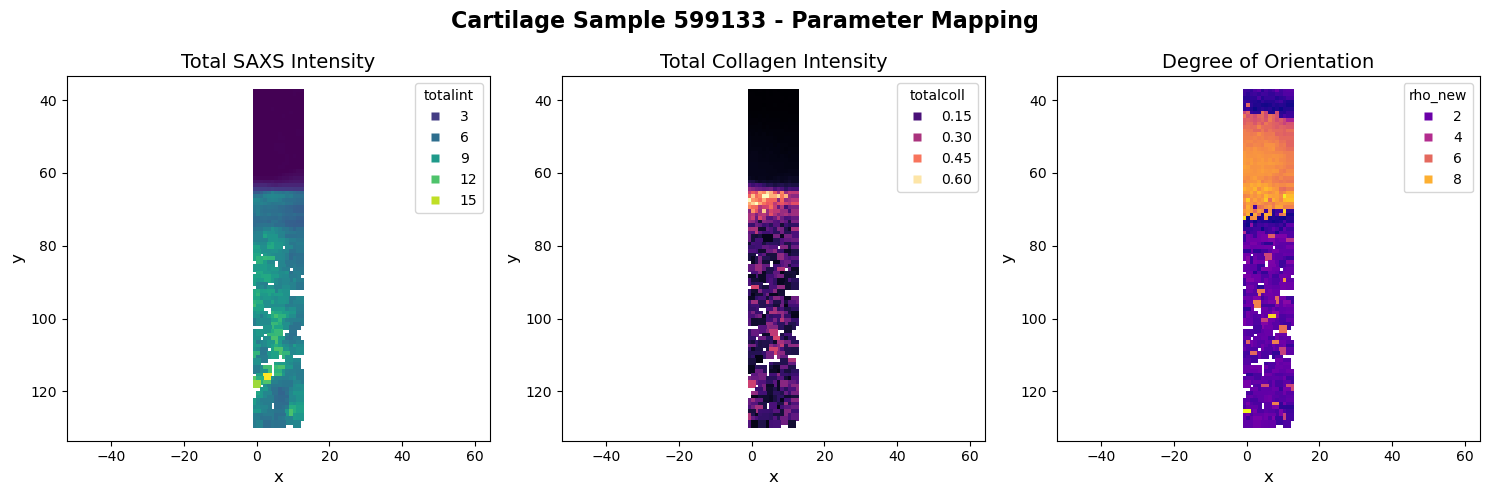

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Cartilage Sample {sample_num} - Parameter Mapping', fontsize=16, fontweight='bold')

# Total Intensity
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='totalint', palette='viridis', # viridis
    edgecolor='none', s=35, marker='s', ax=axes[0]
)
axes[0].set_title('Total SAXS Intensity', fontsize=14)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].axis('equal')
axes[0].invert_yaxis()

# Total Collagen
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='totalcoll', palette='magma', # magma
    edgecolor='none', s=35, marker='s', ax=axes[1]
)
axes[1].set_title('Total Collagen Intensity', fontsize=14)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].axis('equal')
axes[1].invert_yaxis()

# Rho New
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='rho_new', palette='plasma', # plasma
    edgecolor='none', s=35, marker='s', ax=axes[2]
)
axes[2].set_title('Degree of Orientation', fontsize=14)
axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('y', fontsize=12)
axes[2].axis('equal')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Clustering the different samples:

We cluster each sample using HDBSCAN and Kmeans.

 - Compare the different forms of normalisation: $MinMaxScaler$, $StandardScaler$ and $RobustScaler$


 - Features used: `Total Intensity`, `Total Collage`, `rho_new`
 - Add `wa2`
 - switch to features: `rho_new`, `Dnew2`, `Diameter2`, `wa2`
 - Run with all features: `totalint`, `totalcol`, `rho_new`, `wa2`, `Dnew2`, `Diameter2`

 - Compare different values for min_samples in HDBSCAN

 - Compare model performance using control vs low injury vs high injury samples

 ### 1. Define the functions

 #### Metrics Function

In [22]:
def evaluate_clustering(true_labels, predicted_clusters):
    # 1. Calculate percentage of unclustered noise points (-1)
    total_points = len(predicted_clusters)
    noise_count = np.sum(predicted_clusters == -1)
    noise_pct = (noise_count / total_points) * 100 if total_points > 0 else 0.0

    # 2. Filter out HDBSCAN noise points (-1) for metric calculation
    valid_idx = predicted_clusters != -1
    y_true = true_labels[valid_idx]
    y_pred = predicted_clusters[valid_idx]
    
    # If a model puts everything as noise, return NaNs to avoid crashing
    if len(np.unique(y_pred)) == 0:
        print("All points classified as noise (-1). Cannot evaluate.\n")
        return {"ARI": np.nan, "NMI": np.nan, "Homogeneity": np.nan, "Completeness": np.nan, "Noise_%": 100.0}
    
    # 3. Core Metrics
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    homogeneity = homogeneity_score(y_true, y_pred)
    completeness = completeness_score(y_true, y_pred)
    
    # 4. Print Results
    print(f"Adjusted Rand Index (ARI):    {ari:.3f}")
    print(f"Normalized Mutual Info (NMI): {nmi:.3f}")
    print(f"Homogeneity:                  {homogeneity:.3f}")
    print(f"Completeness:                 {completeness:.3f}")
    print(f"Noise Percentage:             {noise_pct:.1f}%\n")

    return {
        "ARI": ari, 
        "NMI": nmi, 
        "Homogeneity": homogeneity, 
        "Completeness": completeness,
        "Noise_%": noise_pct
    }

#### Clustering Function (K-means & HDBSCAN)

In [23]:
def analyse_and_plot_sample(sample_num, df_master, z_params, hdb_csize=40, hdb_msamples=10, scaler_k=MinMaxScaler(), scaler_hdb=MinMaxScaler()):
    # 1. Slice and drop NaNs
    df_sample = df_master[df_master['sample no'] == sample_num].dropna(subset=z_params).copy()

    # 1.2. Filter the a specific zone (e.g. trabecular zone 'tb')
    # df_sample = df_sample[~df_sample['region'].isin(['tb'])].copy()

    # 2. Count the exact number of unique zones in this specific sample's ground truth
    dynamic_k = df_sample['region'].nunique()
    
    # 3. Scale the data (MinMaxScaler, StandardScaler, RobustScaler)
    # K-Means
    X_scaled_k = scaler_k.fit_transform(df_sample[z_params])
    
    # HDBSCAN
    X_scaled_hdb = scaler_hdb.fit_transform(df_sample[z_params])
    
    # 4. K-Means (Dynamic Clusters based on Ground Truth)
    kmeans = KMeans(n_clusters=dynamic_k, random_state=42)
    df_sample['kmeans_cluster'] = kmeans.fit_predict(X_scaled_k)
    
    # 5. HDBSCAN
    hdb = hdbscan.HDBSCAN(min_cluster_size=hdb_csize, min_samples=hdb_msamples)
    df_sample['hdbscan_cluster'] = hdb.fit_predict(X_scaled_hdb)

    print(f"==== METRICS FOR SAMPLE {sample_num} ====")
    print("K-MEANS:")
    k_metrics = evaluate_clustering(df_sample['region'], df_sample['kmeans_cluster'])
    print("HDBSCAN:")
    hdb_metrics = evaluate_clustering(df_sample['region'], df_sample['hdbscan_cluster'])
    print("===================================")
    
    # 6. Plotting the 1x3 Grid
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    state = df_sample['State'].iloc[0] if not df_sample.empty else "Unknown"
    # fig.suptitle(f'High Injury Sample {sample_num}', fontsize=16, fontweight='bold')
    #fig.suptitle(f'Sample {sample_num} ({state.capitalize()})', fontsize=16, fontweight='bold')
    fig.suptitle(f'Clustering Performance - Sample {sample_num}', fontsize=16, fontweight='bold')

    
    # --- Plot Ground Truth ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='region', palette='Set2', 
                    edgecolor='none', s=35, marker='s', ax=axes[0])
    axes[0].set_title(f'Ground Truth ({dynamic_k} Regions)', fontsize=14)
    
    # --- Plot K-Means ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='kmeans_cluster', palette=my_colors, 
                    edgecolor='none', s=35, marker='s', ax=axes[1])
    axes[1].set_title(f'K-Means (k={dynamic_k})', fontsize=14)
    
    # --- Plot HDBSCAN ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='hdbscan_cluster', palette=my_colors, 
                    edgecolor='none', s=35, marker='s', ax=axes[2], legend='full')
    axes[2].set_title(f'HDBSCAN', fontsize=14) # HDBSCAN (size={hdb_csize}, min={hdb_msamples}
    
    # Clean up all axes
    for ax in axes:
        ax.axis('equal')
        ax.invert_yaxis()
        ax.set_xlabel('x [mm]', fontsize=12)
        ax.set_ylabel('y [mm]', fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

    return k_metrics, hdb_metrics

### 2. Check the minimum size of the clusters

In [24]:
# 1. Filter out missing data just like in the clustering pipeline
z_parameters = ['Dnew2', 'Diameter2', 'rho_new', 'iy']
df_valid = df_import.dropna(subset=z_parameters).copy()

# 2. Group by sample and region to count the number of pixels
region_sizes = df_valid.groupby(['sample no', 'region']).size().reset_index(name='pixel_count')

# 3. Sort to see the absolute smallest regions in the dataset
smallest_regions = region_sizes.sort_values(by='pixel_count').head(15)

print("--- 15 Smallest Regions Across All Samples ---")
display(smallest_regions)

# 4. Get general summary statistics to see the distribution
print("\n--- Summary Statistics of Region Sizes ---")
display(region_sizes['pixel_count'].describe().to_frame())

--- 15 Smallest Regions Across All Samples ---


,sample no,region,pixel_count
257,599199,sz,1
222,599192,sz,13
242,599196,sz,13
122,599145,sz,14
34,599119,tb,14
277,599203,sz,14
80,599129,dz,14
38,599120,sz,16
202,599179,sz,16
109,599135,sz,16



--- Summary Statistics of Region Sizes ---


,pixel_count
count,290.000000
mean,163.786207
std,138.693193
min,1.000000
25%,47.500000
50%,115.000000
75%,262.500000
max,616.000000


### 3. Run the modles

In [25]:
sample_counts = df_import.groupby('Sample')['sample no'].nunique()

print("Number of unique samples per category:")
print(sample_counts)

Number of unique samples per category:
Sample
aged_control       10
aged_highinjury    10
aged_lowinjury     10
control            10
highinjury         10
lowinjury          10
Name: sample no, dtype: int64


==== METRICS FOR SAMPLE 599112 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.776
Normalized Mutual Info (NMI): 0.803
Homogeneity:                  0.783
Completeness:                 0.824
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.820
Normalized Mutual Info (NMI): 0.842
Homogeneity:                  0.822
Completeness:                 0.864
Noise Percentage:             3.7%



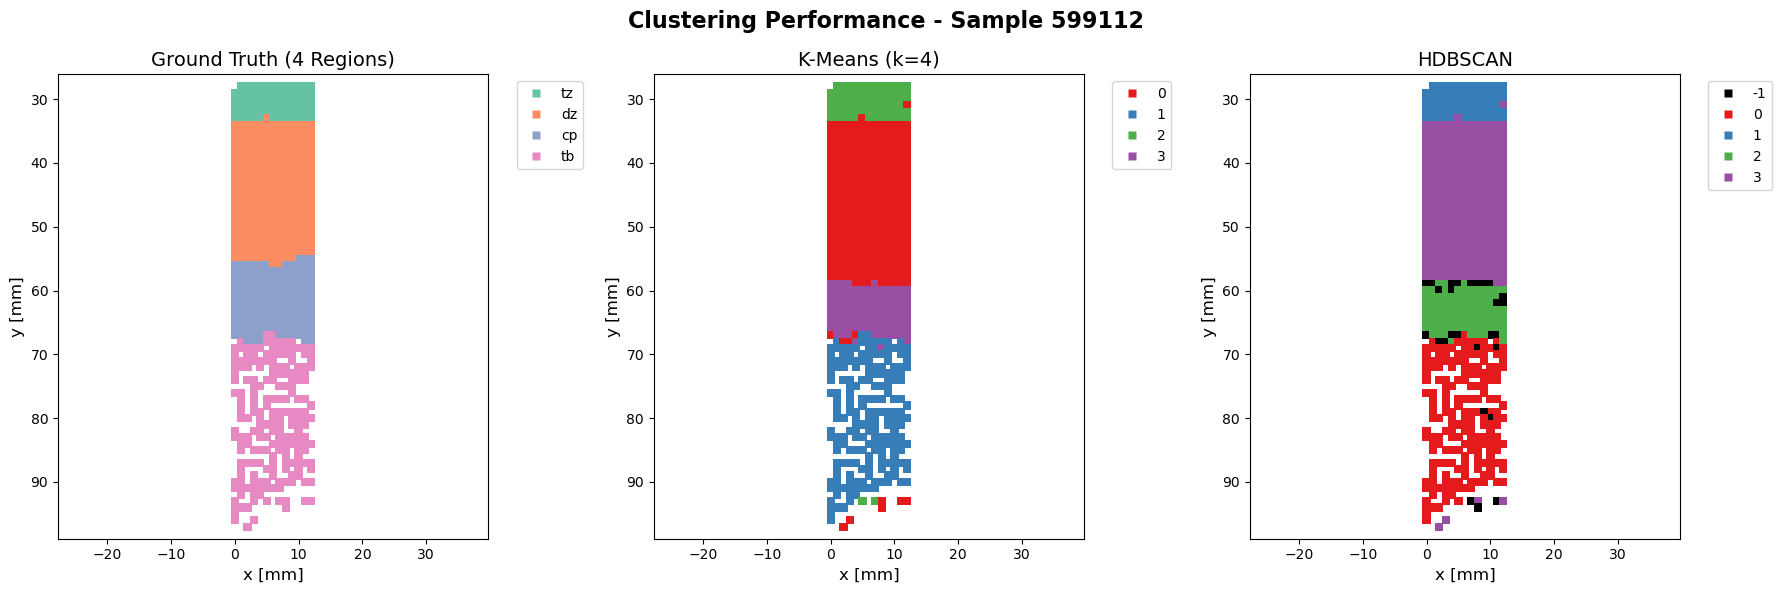

==== METRICS FOR SAMPLE 599118 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.689
Normalized Mutual Info (NMI): 0.605
Homogeneity:                  0.546
Completeness:                 0.678
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.756
Normalized Mutual Info (NMI): 0.731
Homogeneity:                  0.841
Completeness:                 0.646
Noise Percentage:             24.0%



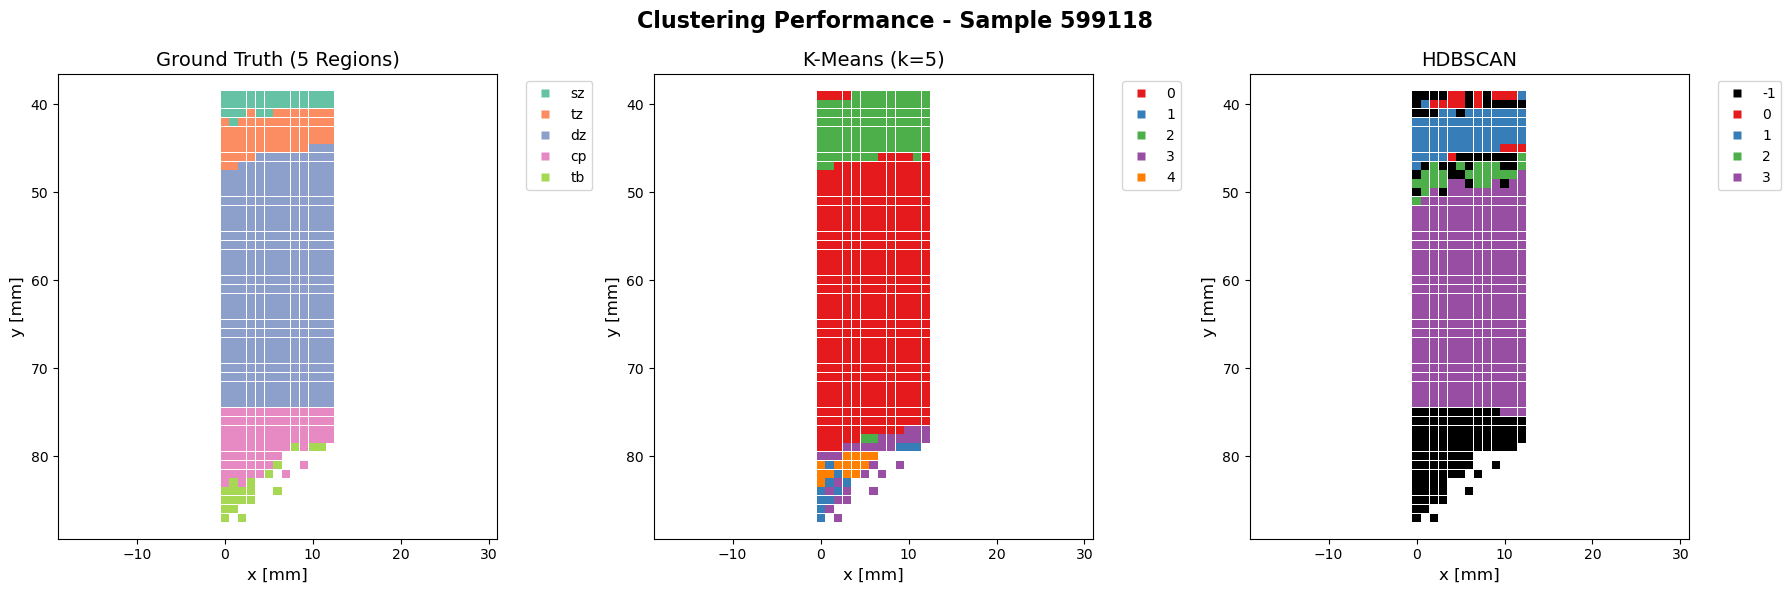

==== METRICS FOR SAMPLE 599124 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.726
Normalized Mutual Info (NMI): 0.743
Homogeneity:                  0.715
Completeness:                 0.773
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.898
Normalized Mutual Info (NMI): 0.866
Homogeneity:                  0.867
Completeness:                 0.865
Noise Percentage:             11.2%



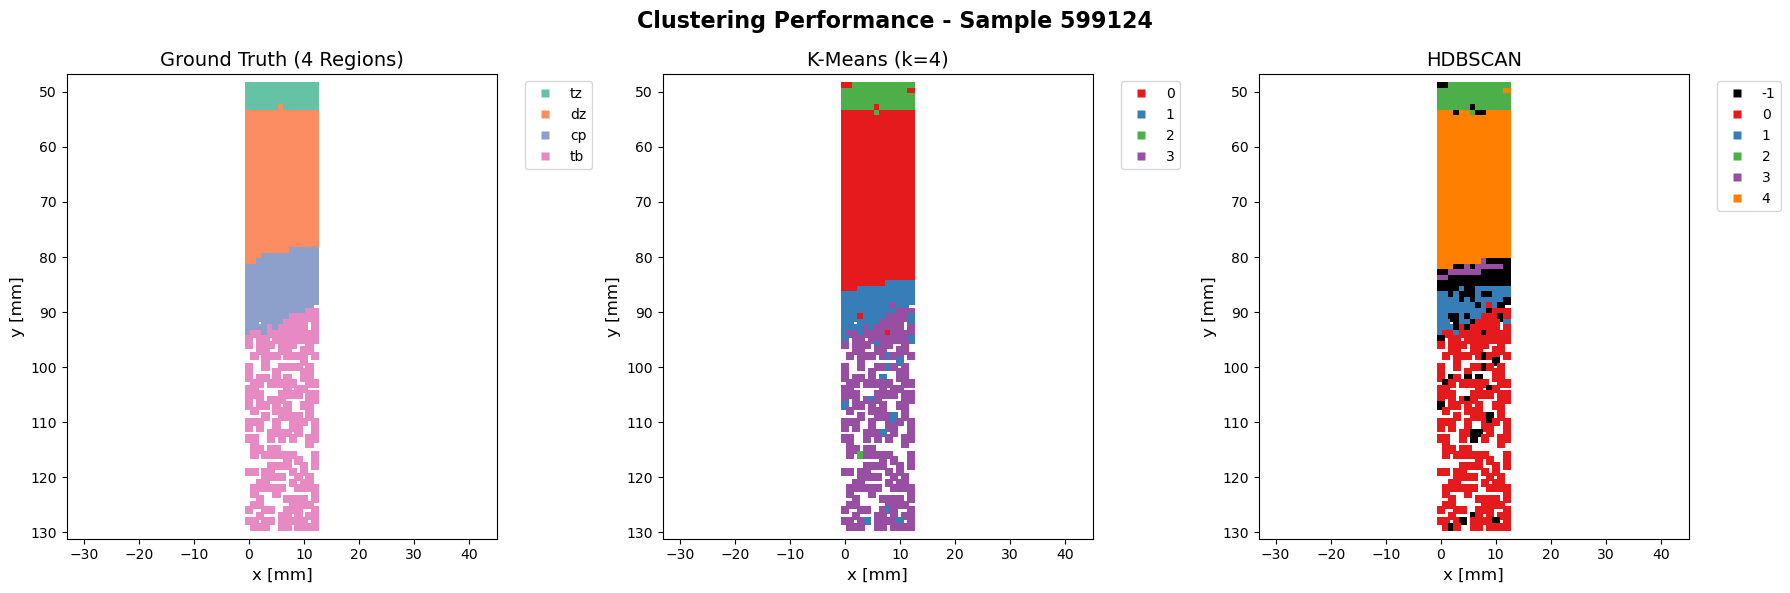

==== METRICS FOR SAMPLE 599130 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.809
Normalized Mutual Info (NMI): 0.777
Homogeneity:                  0.761
Completeness:                 0.794
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.860
Normalized Mutual Info (NMI): 0.834
Homogeneity:                  0.803
Completeness:                 0.867
Noise Percentage:             4.1%



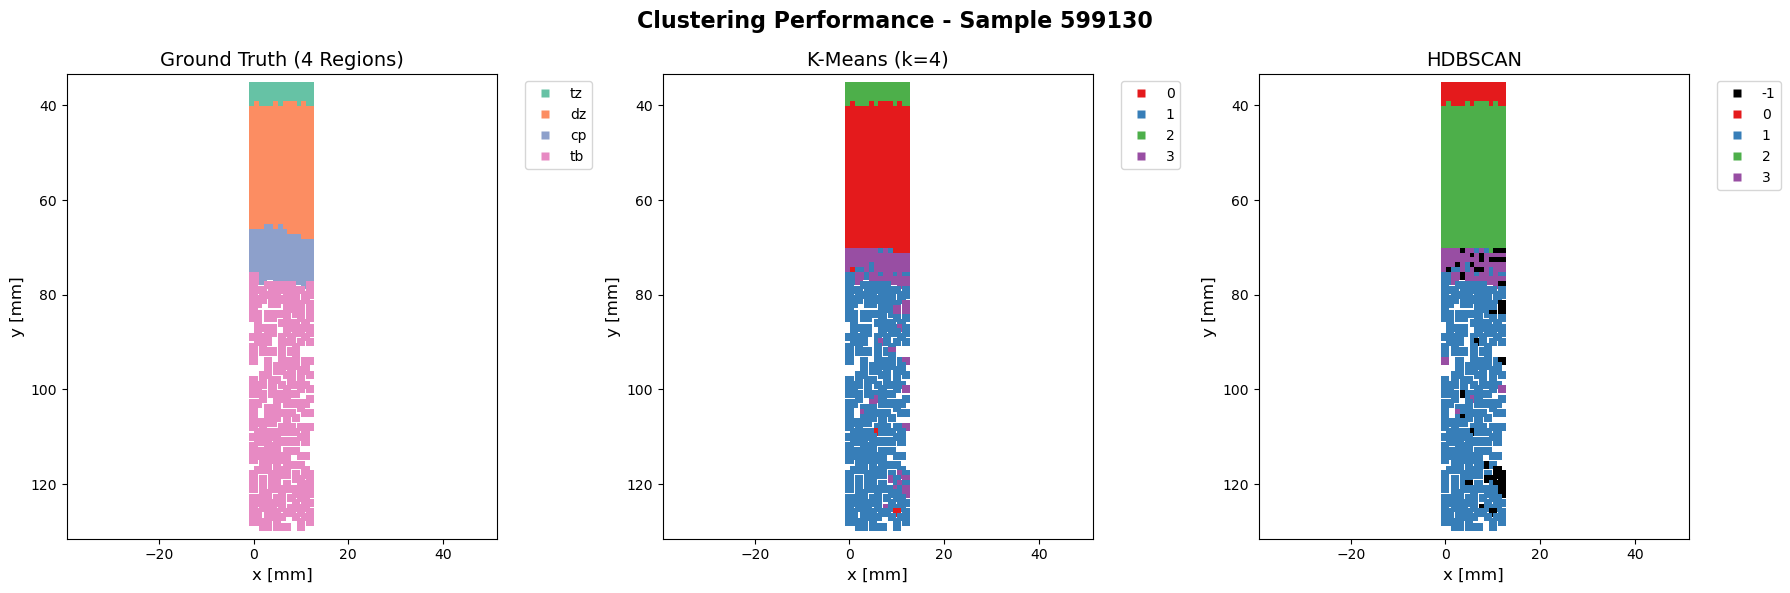

==== METRICS FOR SAMPLE 599134 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.705
Normalized Mutual Info (NMI): 0.761
Homogeneity:                  0.821
Completeness:                 0.709
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.939
Normalized Mutual Info (NMI): 0.891
Homogeneity:                  0.862
Completeness:                 0.922
Noise Percentage:             3.7%



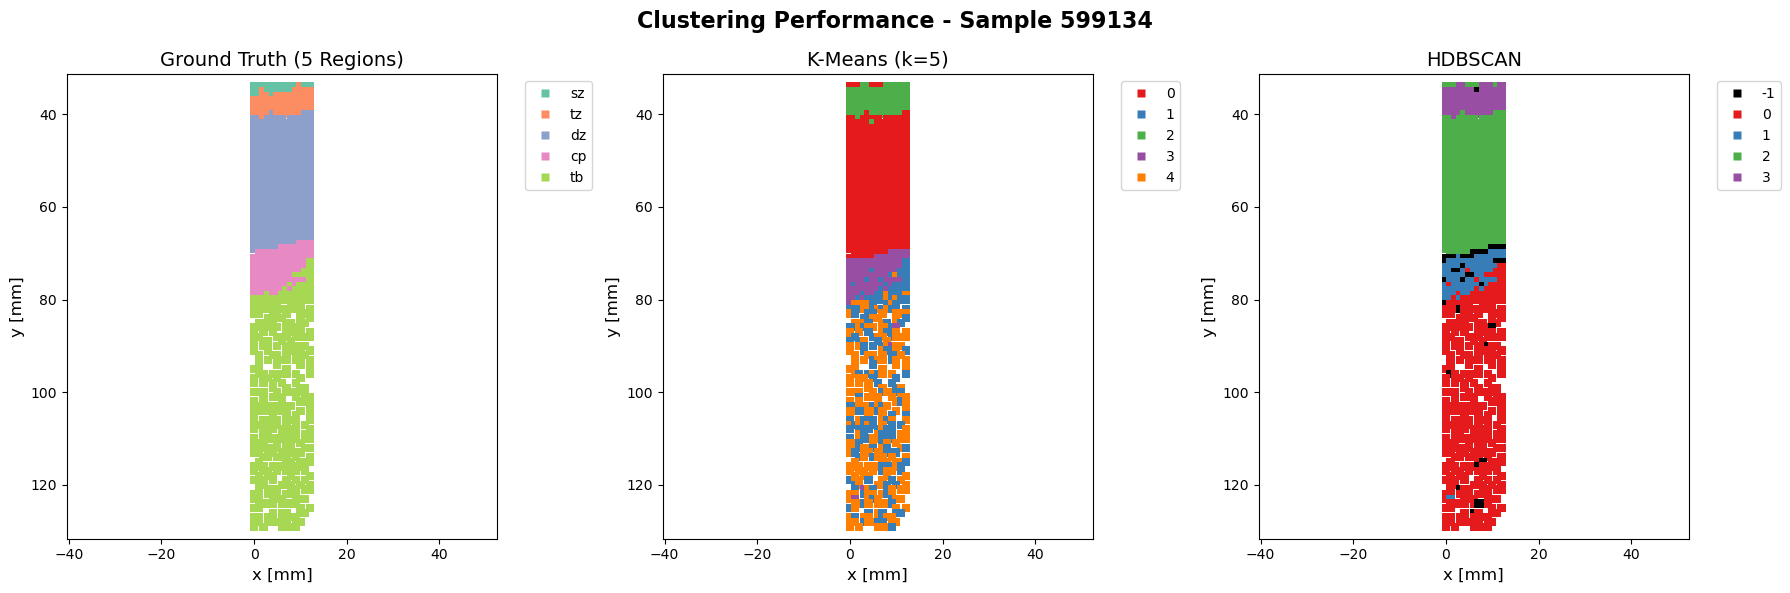

==== METRICS FOR SAMPLE 599113 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.697
Normalized Mutual Info (NMI): 0.742
Homogeneity:                  0.721
Completeness:                 0.764
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.751
Normalized Mutual Info (NMI): 0.799
Homogeneity:                  0.774
Completeness:                 0.825
Noise Percentage:             7.2%



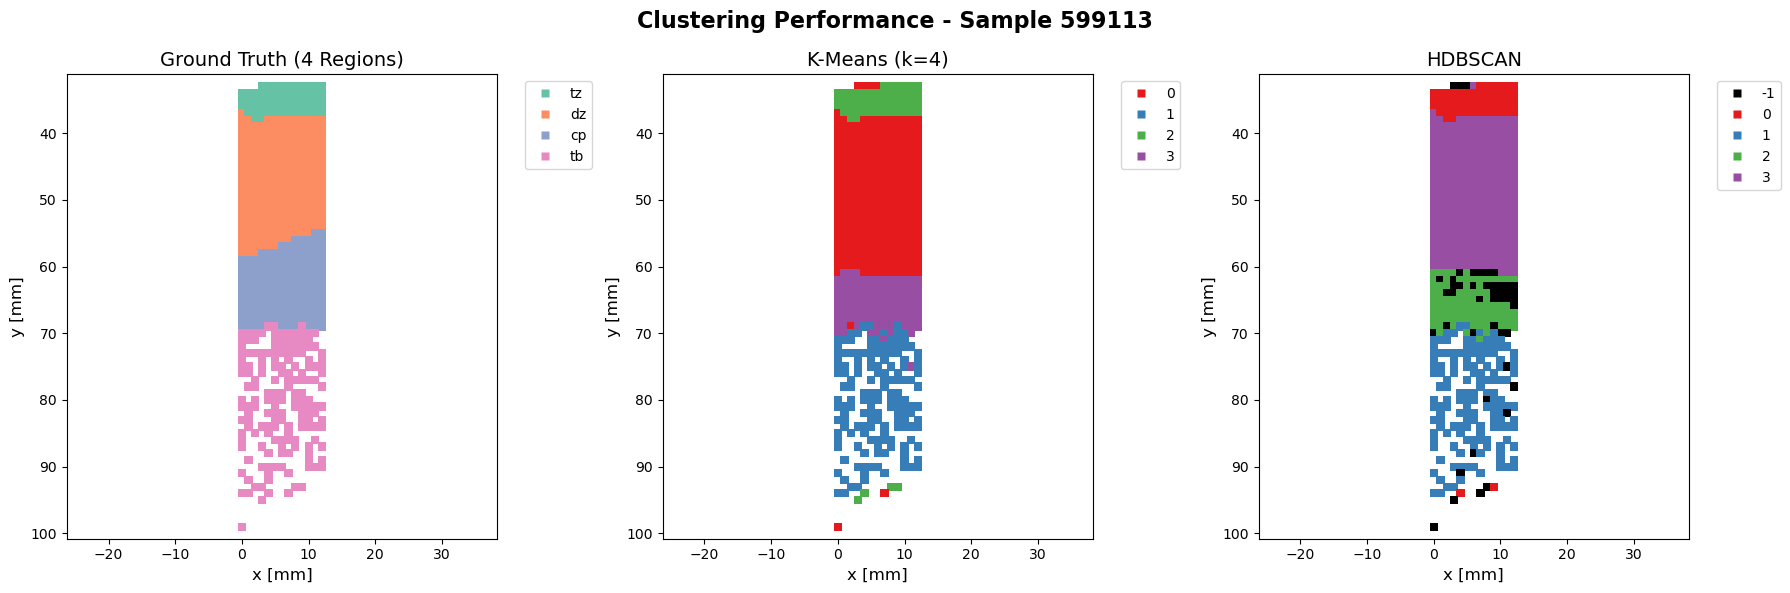

==== METRICS FOR SAMPLE 599119 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.674
Normalized Mutual Info (NMI): 0.663
Homogeneity:                  0.600
Completeness:                 0.742
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.696
Normalized Mutual Info (NMI): 0.661
Homogeneity:                  0.521
Completeness:                 0.902
Noise Percentage:             16.2%



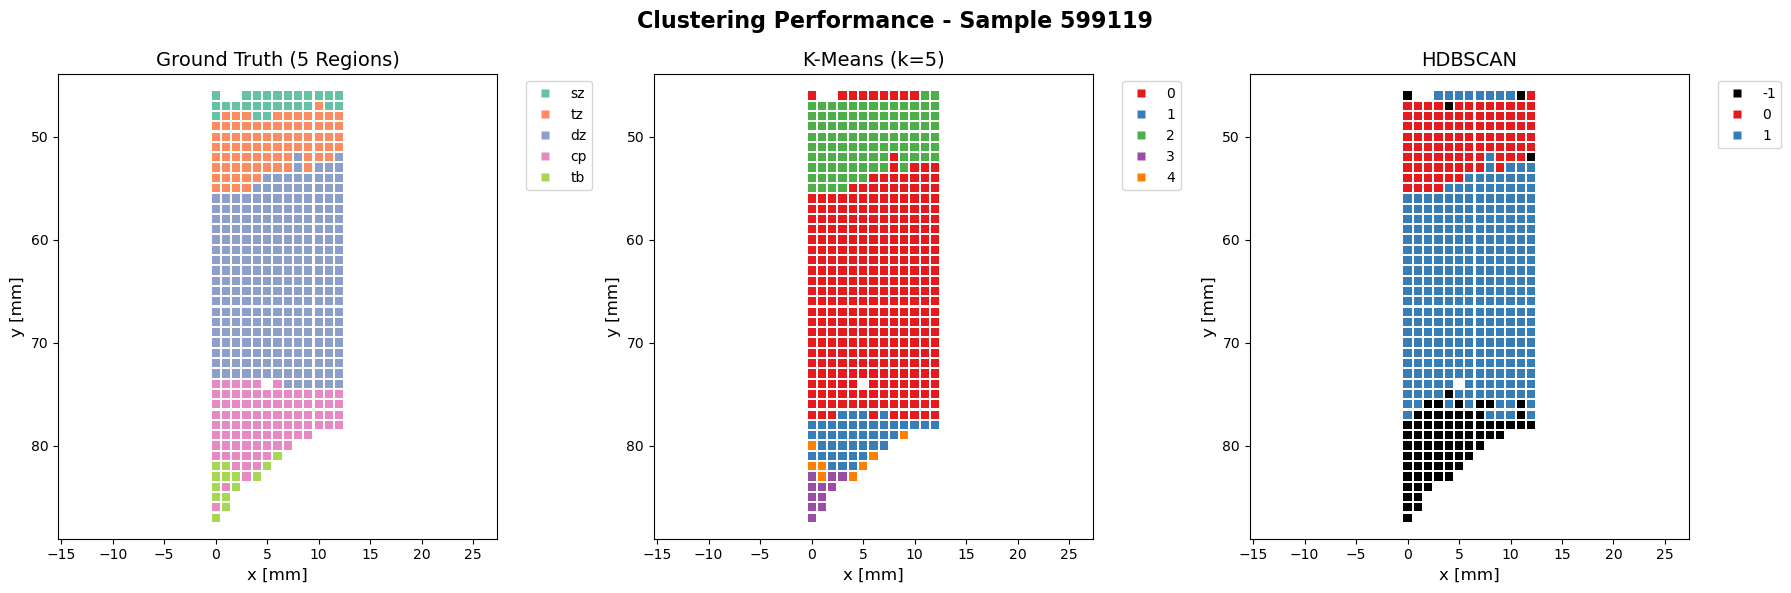

==== METRICS FOR SAMPLE 599125 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.686
Normalized Mutual Info (NMI): 0.765
Homogeneity:                  0.731
Completeness:                 0.802
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.694
Normalized Mutual Info (NMI): 0.791
Homogeneity:                  0.746
Completeness:                 0.842
Noise Percentage:             3.7%



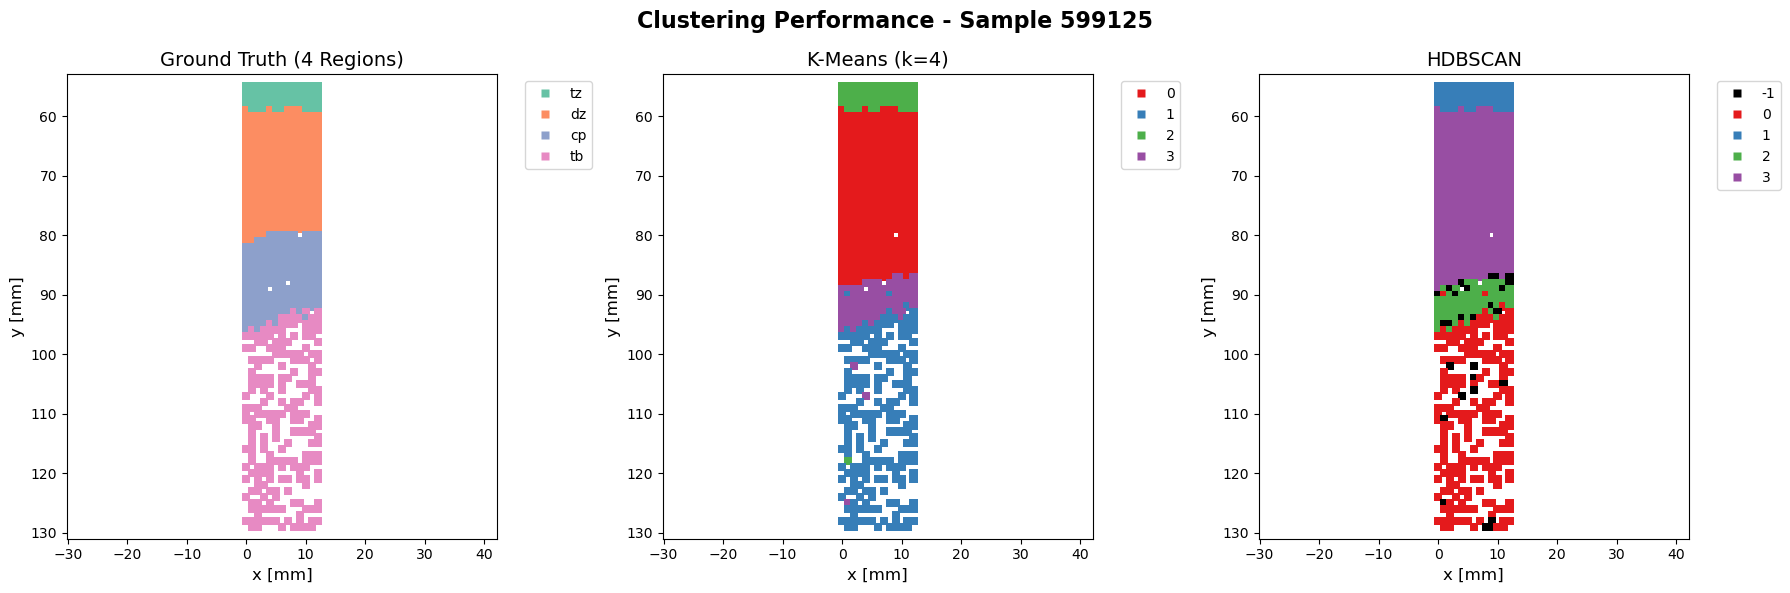

==== METRICS FOR SAMPLE 599131 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.754
Normalized Mutual Info (NMI): 0.757
Homogeneity:                  0.766
Completeness:                 0.747
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.894
Normalized Mutual Info (NMI): 0.856
Homogeneity:                  0.834
Completeness:                 0.879
Noise Percentage:             3.7%



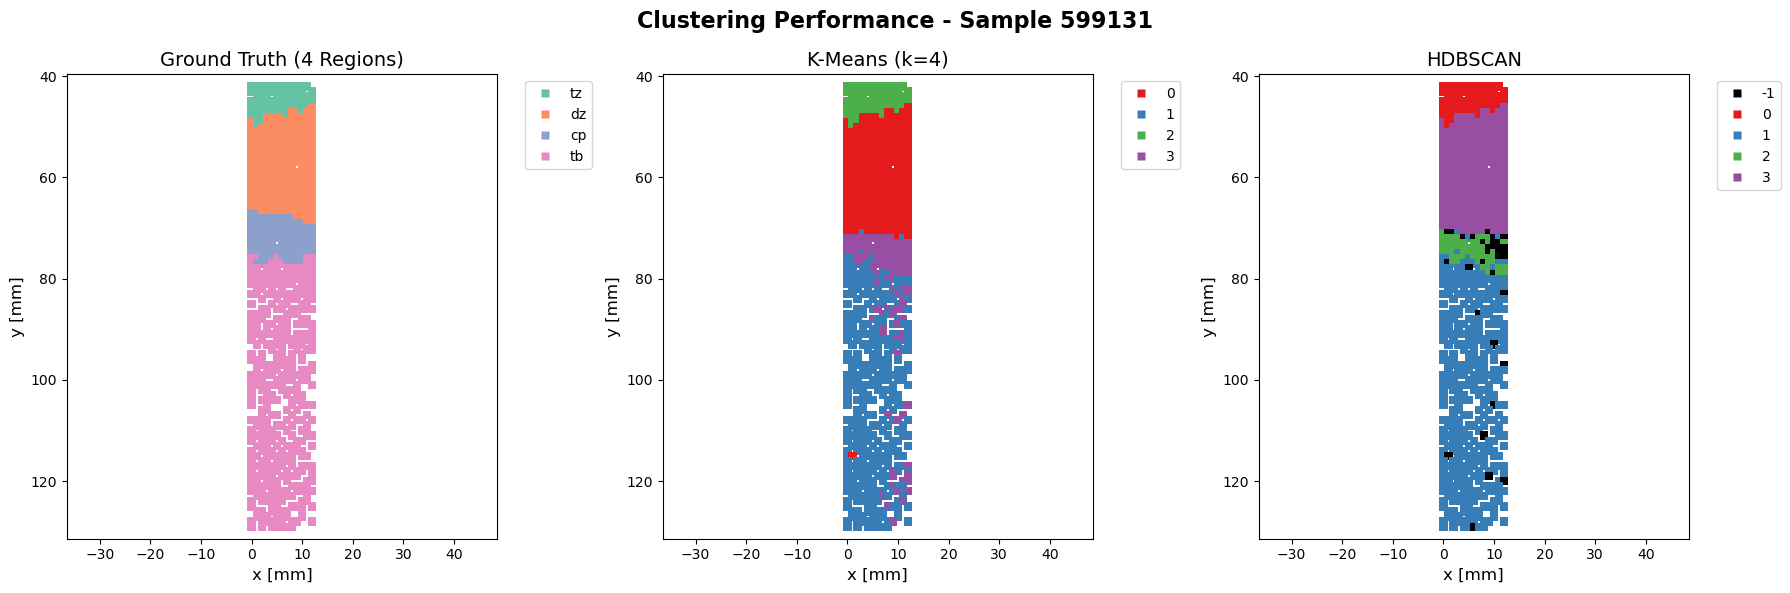

In [ ]:
# ==========================================
# Selecting the sampples to run
# ==========================================

# Run ALL 60 samples (for stage 1, 2 and 3)
samples_to_run = df_import['sample no'].unique()

# Run ONLY Control samples (Stage 4)
#samples_to_run = df_import[df_import['Sample'] == 'control']['sample no'].unique()

# Run ONLY Low Injury samples (Stage 4)
# samples_to_run = df_import[df_import['Sample'] == 'lowinjury']['sample no'].unique()

# Run ONLY High Injury samples (Stage 4)
# samples_to_run = df_import[df_import['Sample'] == 'highinjury']['sample no'].unique()
# samples_to_run = [599133, 599134, 599135]


# ==========================================
# RUN PIPELINE
# ==========================================

# Features: 'totalint', 'totalcoll', 'rho_new', 'Dnew2', 'Diameter2', 'wa2'
z_parameters = ['rho_new', 'totalint', 'totalcoll'] 
#z_parameters = ['rho_new', 'Dnew2', 'Diameter2','wa2', 'totalint', 'totalcoll']

all_k_scores = []
all_hdb_scores = []

# Run models
for current_sample in samples_to_run:
    k_res, hdb_res = analyse_and_plot_sample(   # returns k_metrics, hdb_metrics from analyse function as k_res and hdb_res
        sample_num=current_sample, 
        df_master=df_import, 
        z_params=z_parameters, 
        hdb_csize= 13,     # min_cluster_size
        hdb_msamples= 13,   # min_samples
        scaler_k=StandardScaler(),   # StandardScaler vs MinMacScaler vs RobustScaler
        scaler_hdb=StandardScaler()

    )

    if k_res: all_k_scores.append(k_res)
    if hdb_res: all_hdb_scores.append(hdb_res)


# Overall Metrics
print("\n" + "="*40)
print("     OVERALL AVERAGES ACROSS ALL SAMPLES")
print("="*40)

print("\n--- K-MEANS AVERAGE ---")
display(pd.DataFrame(all_k_scores).mean().round(3).to_frame(name='Mean Score'))

print("\n--- HDBSCAN AVERAGE ---")
display(pd.DataFrame(all_hdb_scores).mean().round(3).to_frame(name='Mean Score'))

#### End

# plots
## 1. Kmeans (Stage 1)

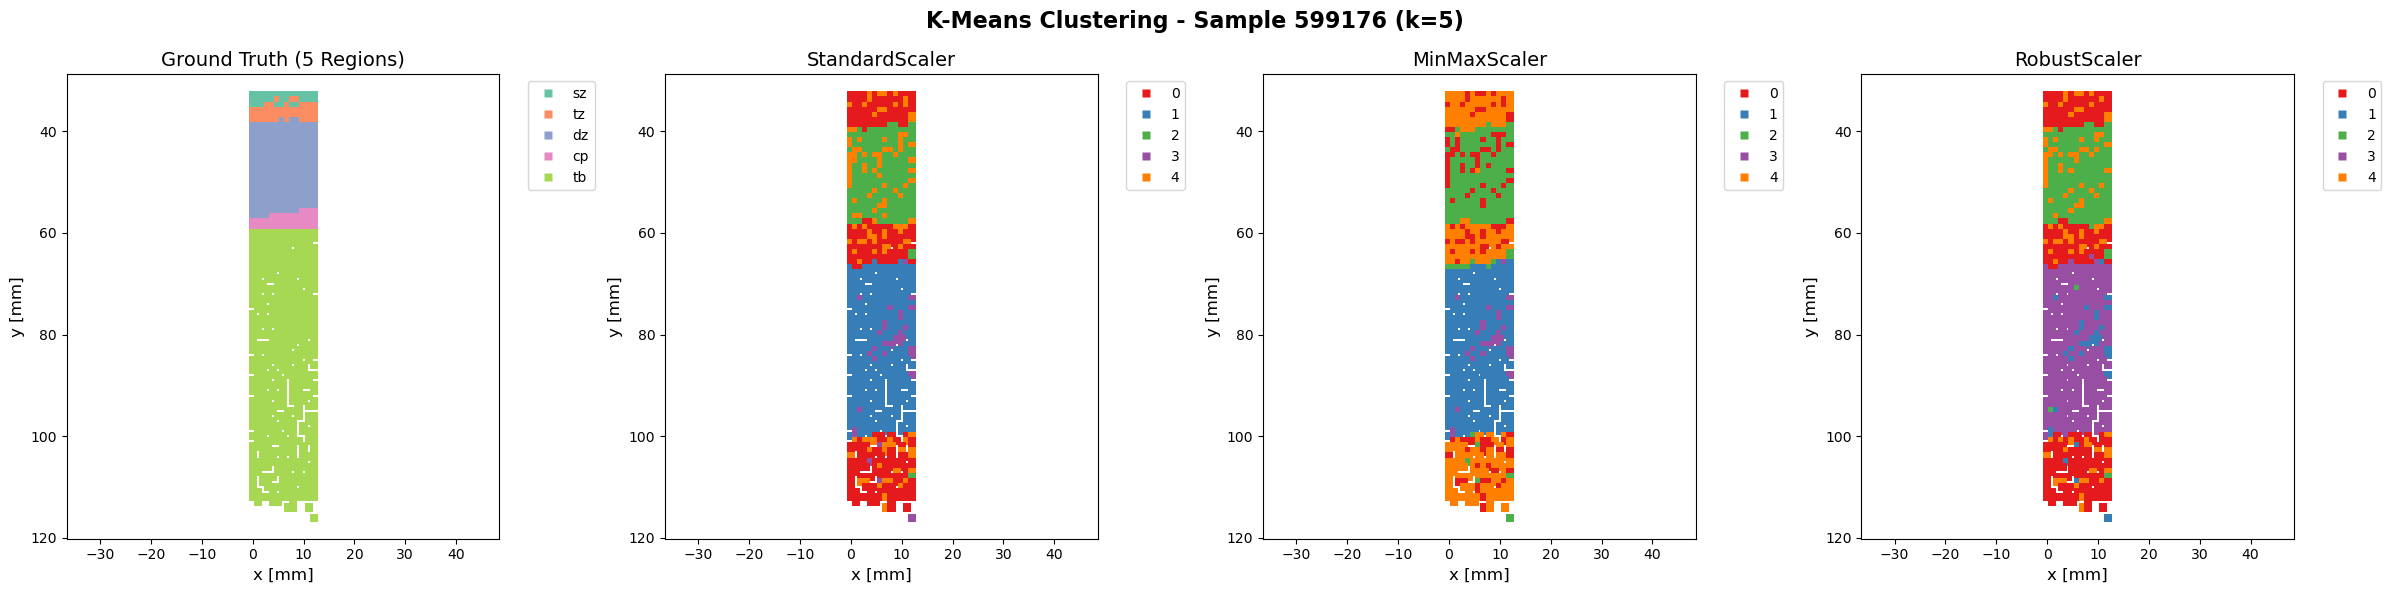

In [ ]:
# ==========================================
# 1. CHOOSE YOUR SAMPLE HERE
# ==========================================
target_sample = 599176  # Swap this to a healthy 5-region control
z_params = ['rho_new', 'totalint', 'totalcoll']

# Isolate the data and drop NaNs
df_plot = df_import[df_import['sample no'] == target_sample].dropna(subset=z_params).copy()
k_val = df_plot['region'].nunique()

# ==========================================
# 2. SCALE THE DATA (3 WAYS)
# ==========================================
X_std = StandardScaler().fit_transform(df_plot[z_params])
X_minmax = MinMaxScaler().fit_transform(df_plot[z_params])
X_rob = RobustScaler().fit_transform(df_plot[z_params])

# ==========================================
# 3. RUN K-MEANS (3 TIMES)
# ==========================================
km = KMeans(n_clusters=k_val, random_state=42)

df_plot['k_std'] = km.fit_predict(X_std)
df_plot['k_minmax'] = km.fit_predict(X_minmax)
df_plot['k_rob'] = km.fit_predict(X_rob)

# ==========================================
# 4. PLOT THE 1x4 GRID
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'K-Means Clustering - Sample {target_sample} (k={k_val})', fontsize=16, fontweight='bold')

# --- Plot 1: Ground Truth ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='region', palette='Set2', 
                edgecolor='none', s=35, marker='s', ax=axes[0])
axes[0].set_title(f'Ground Truth ({k_val} Regions)', fontsize=14)

# --- Plot 2: Standard Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_std', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[1])
axes[1].set_title('StandardScaler', fontsize=14)

# --- Plot 3: MinMax Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_minmax', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[2])
axes[2].set_title('MinMaxScaler', fontsize=14)

# --- Plot 4: Robust Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_rob', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[3])
axes[3].set_title('RobustScaler', fontsize=14)

# Clean up axes
for ax in axes:
    ax.axis('equal')
    ax.invert_yaxis()
    ax.set_xlabel('x [mm]', fontsize=12)
    ax.set_ylabel('y [mm]', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## HDBSCAN (Stage 1)

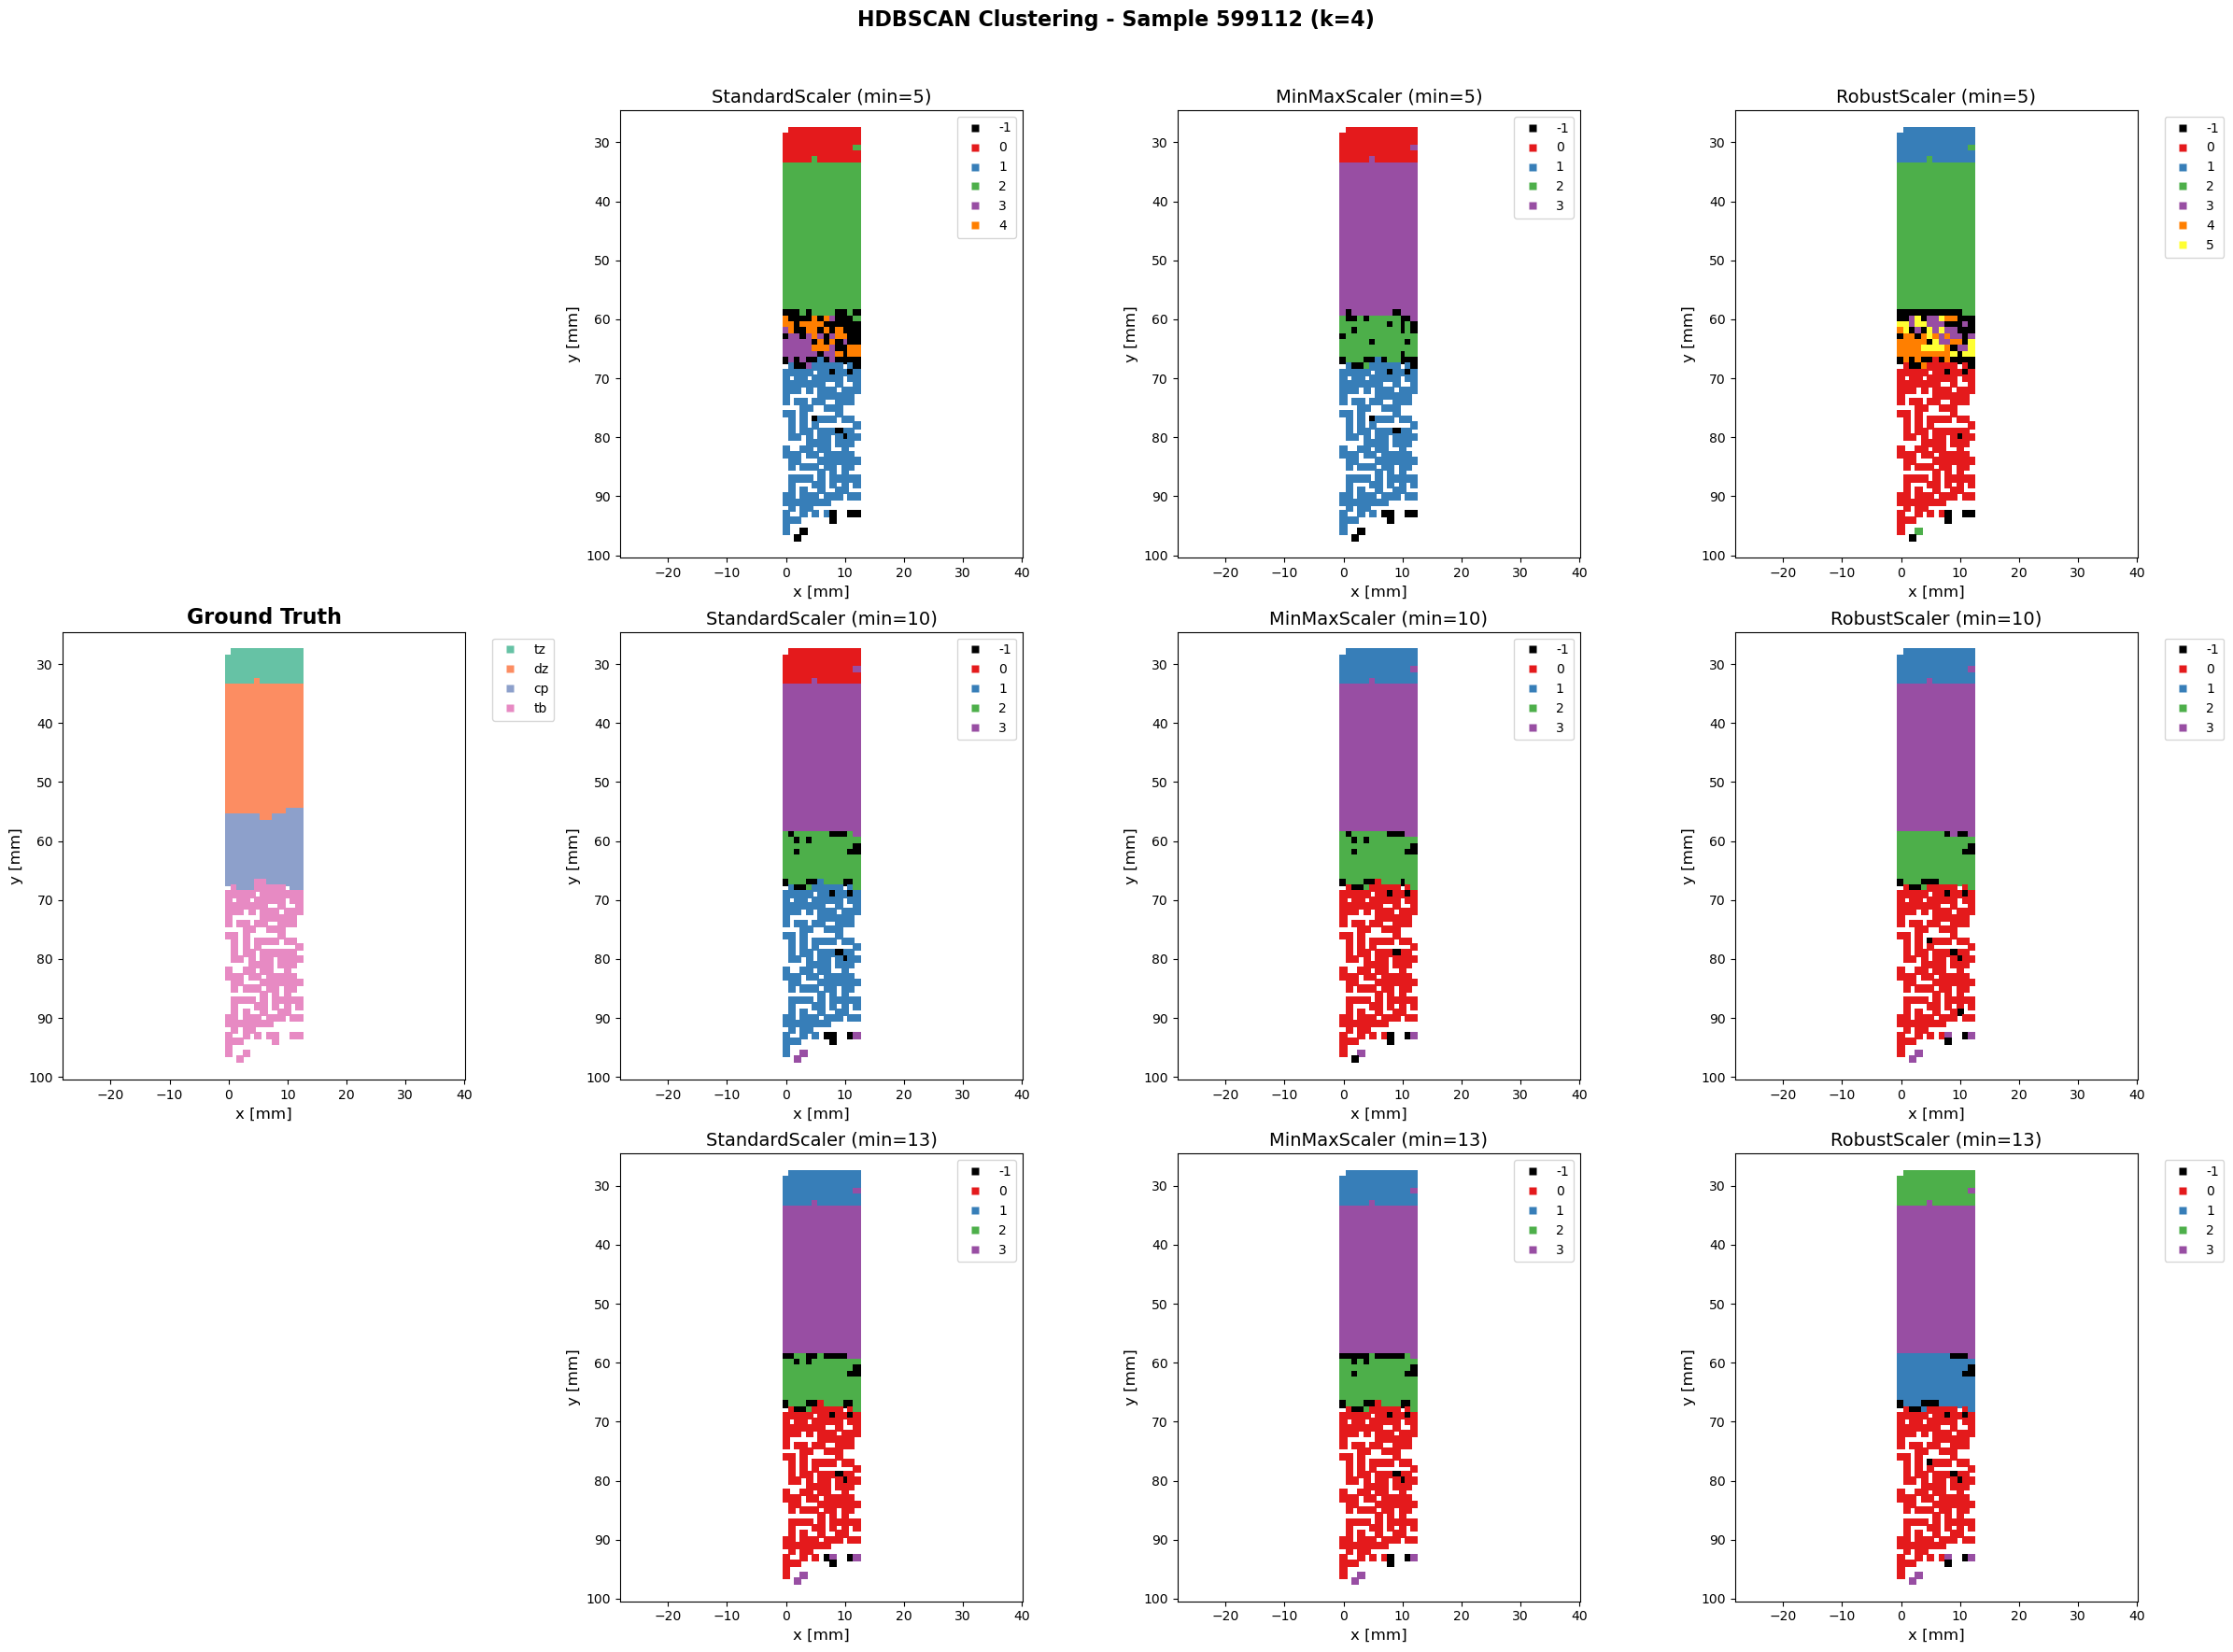

In [ ]:
# ==========================================
# 1. CHOOSE YOUR SAMPLE HERE
# ==========================================
target_sample = 599112 # Keep hunting for a 5-region one!
z_params = ['rho_new', 'totalint', 'totalcoll']
hdb_csize = 13

# Isolate the data
df_plot = df_import[df_import['sample no'] == target_sample].dropna(subset=z_params).copy()
k_val = df_plot['region'].nunique()

# ==========================================
# 2. SCALE THE DATA (3 WAYS)
# ==========================================
X_std = StandardScaler().fit_transform(df_plot[z_params])
X_minmax = MinMaxScaler().fit_transform(df_plot[z_params])
X_rob = RobustScaler().fit_transform(df_plot[z_params])

# ==========================================
# 3. SETUP THE 3x4 GRID
# ==========================================
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
fig.suptitle(f'HDBSCAN Clustering - Sample {target_sample} (k={k_val})', fontsize=16, fontweight='bold')

# Hide Top-Left and Bottom-Left axes
axes[0, 0].axis('off')
axes[2, 0].axis('off')

# Plot Ground Truth in the Middle-Left (Row 1, Col 0)
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='region', palette='Set2', 
                edgecolor='none', s=35, marker='s', ax=axes[1, 0])
axes[1, 0].set_title(f'Ground Truth', fontsize=16, fontweight='bold')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# 4. RUN AND PLOT THE 3x3 MATRIX
# ==========================================
min_samples_list = [5, 10, 13]
scalers = [('StandardScaler', X_std), ('MinMaxScaler', X_minmax), ('RobustScaler', X_rob)]

for row_idx, ms in enumerate(min_samples_list):
    for col_idx, (s_name, X_scaled) in enumerate(scalers):
        
        # Shift col_idx by 1 because Col 0 is for the Ground Truth
        actual_col = col_idx + 1
        
        # Run HDBSCAN
        hdb = hdbscan.HDBSCAN(min_cluster_size=hdb_csize, min_samples=ms)
        labels = hdb.fit_predict(X_scaled)
        
        # Plot
        sns.scatterplot(x=df_plot['ix'], y=df_plot['iy'], hue=labels, palette=my_colors, 
                        edgecolor='none', s=35, marker='s', ax=axes[row_idx, actual_col])
        axes[row_idx, actual_col].set_title(f'{s_name} (min={ms})', fontsize=14)
        
        # Add legend only to the far-right column to avoid clutter
        if actual_col == 3:
            axes[row_idx, actual_col].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# 5. CLEANUP FORMATTING
# ==========================================
for r in range(3):
    for c in range(4):
        if (r == 0 and c == 0) or (r == 2 and c == 0):
            continue  # Skip the hidden axes
            
        axes[r, c].axis('equal')
        axes[r, c].invert_yaxis()
        axes[r, c].set_xlabel('x [mm]', fontsize=12)
        axes[r, c].set_ylabel('y [mm]', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Give the main title some breathing room
plt.show()